# pymoo NSGA-II — Multi-Objective Optimization for Image Classification

**MOML Assignment** — Prof. Aswin Kannan · Niranjan Gopal, Divyam Sareen · Due 2026-04-28

Optimizes 3 conflicting objectives over a CNN search space using **pymoo NSGA-II**:

1. **Maximize** classification accuracy (top-1 on test set)
2. **Minimize** inference time (ms / sample, CPU, batch=1)
3. **Minimize** model size (trainable parameters)

Hard wall-clock cap: **≤ 1.5 hours**, designed for running concurrently with the BoTorch notebook on the same GPU.

Why NSGA-II for this problem: the search space is mostly categorical/integer, which pymoo's `MixedVariableMating` handles natively. Crowding-distance pressure produces a diverse front under domination-based selection. See `docs/PROJECT_DESCRIPTION.md` for the full setup; see the BoTorch notebook for the head-to-head comparison.

In [1]:
# --- Imports & path setup -------------------------------------------------
import sys, os, json
from pathlib import Path

# This notebook lives in notebooks/; make src/ importable.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data_loader import DEVICE, PROJECT_ROOT, get_dataset_info
from moo_pymoo import run_pymoo_study
from analyze_study import analyze

print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
if str(DEVICE) == "cuda":
    import torch
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

Device       : cuda
Project root : D:\forKrishna\MOML
GPU          : NVIDIA GeForce GTX 1650


d:\forKrishna\MOML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Defaults give **80 evaluations** (pop=20 × n_gen=4) and target ≤1.5h on a small CUDA GPU even when the BoTorch notebook is running concurrently and competing for GPU time.

| Knob | Default | What it does |
|---|---|---|
| `DATASET` | `fashion_mnist` | One of `fashion_mnist`, `cifar10`. FashionMNIST is ~2× faster per trial. |
| `POP_SIZE` | 20 | NSGA-II population. Larger = more diverse front, more evaluations per generation. |
| `N_GEN` | 4 | Generations. Total evals = `POP_SIZE × N_GEN` = 80. |
| `TRAIN_SUBSET_SIZE` | 8000 | Samples used per training run. Smaller = faster trials, noisier objectives. |
| `SEED` | 42 | Deterministic. Per-trial seed = `SEED + trial_index`. |
| `NUM_WORKERS` | 2 | DataLoader workers. Set to 0 on Windows if you hit issues. |

Set `RUN_SMOKE_TEST = True` to do a 1-2 minute sanity check before the full run.

Search space is defined in `src/moo_pymoo.py:make_search_space()` and is **identical** to the one in `src/moo_botorch.py`'s `SearchSpace`, so the two studies are directly comparable.

In [2]:
# --- Configuration --------------------------------------------------------
DATASET           = "fashion_mnist"   # "fashion_mnist" or "cifar10"
POP_SIZE          = 20
N_GEN             = 4
TRAIN_SUBSET_SIZE = 8000
SEED              = 42
NUM_WORKERS       = 2

RUN_SMOKE_TEST    = False             # Toggle True for a 1-2 min sanity run first.
COMPARE_PARETO    = None              # Set to a botorch pareto_front.csv path for joint-front
                                       # + GD comparison in the analysis step (see last cell
                                       # for an auto-discovered path).

info = get_dataset_info(DATASET)
print(f"Dataset        : {DATASET}  (classes={info['num_classes']}, native res={info['default_resolution']})")
print(f"Total evals    : {POP_SIZE * N_GEN} (pop_size {POP_SIZE} × n_gen {N_GEN})")
print(f"Train subset   : {TRAIN_SUBSET_SIZE:,} samples per trial")

Dataset        : fashion_mnist  (classes=10, native res=28)
Total evals    : 80 (pop_size 20 × n_gen 4)
Train subset   : 8,000 samples per trial


## (Optional) Smoke test

Tiny configuration that runs in ~1 minute and exercises the full pipeline (NSGA-II loop, CSV streaming, Pareto extraction, analysis, plotting). Skip if you trust the setup.

In [3]:
if RUN_SMOKE_TEST:
    import tempfile
    with tempfile.TemporaryDirectory() as td:
        smoke_summary, smoke_dir = run_pymoo_study(
            dataset_name=DATASET,
            pop_size=4,
            n_gen=2,
            train_subset_size=1000,
            seed=7,
            num_workers=0,
            output_root=td,
        )
        smoke_metrics = analyze(smoke_dir)
        print("\nSmoke test passed.")
        print(f"  trials   : {smoke_summary['n_trials_completed']}")
        print(f"  pareto   : {smoke_summary['n_pareto_points']}")
        print(f"  hv       : {smoke_metrics['hypervolume']:,.0f}")
        print(f"  spacing  : {smoke_metrics['spacing']:.4f}")
else:
    print("Skipped (set RUN_SMOKE_TEST = True to run).")

Skipped (set RUN_SMOKE_TEST = True to run).


## Full optimization run

Streams every trial to `trials.csv` as it completes, so a kernel crash mid-run loses no work. Stdout shows one line per trial plus a per-generation summary.

Expected wall-clock: **~30-50 min solo** on a GTX 1650 with `train_subset_size=8000`. Budget up to **~80 min** when running concurrently with the BoTorch notebook (both share the GPU and roughly double each other's per-trial time).

In [4]:
summary, study_dir = run_pymoo_study(
    dataset_name=DATASET,
    pop_size=POP_SIZE,
    n_gen=N_GEN,
    train_subset_size=TRAIN_SUBSET_SIZE,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

print("\n" + "=" * 70)
print(f"Study dir : {study_dir}")
print(f"Wall time : {summary['elapsed_seconds']/60:.1f} min")
print(f"Pareto    : {summary['n_pareto_points']} non-dominated points (final population)")

  trial 000 | acc=0.6080 | ms=  0.425 | params=    3,658 |  86.7s | plain/1L/16ch
  trial 001 | acc=0.8616 | ms=  0.888 | params=   70,186 |  71.3s | plain/4L/16ch
  trial 002 | acc=0.8039 | ms=  0.455 | params=    4,762 |  91.5s | plain/2L/8ch
  trial 003 | acc=0.6704 | ms=  0.798 | params=   28,618 |  46.1s | plain/2L/32ch
  trial 004 | acc=0.7828 | ms=  0.486 | params=   28,618 |  67.5s | plain/2L/32ch
  trial 005 | acc=0.8608 | ms=  0.761 | params=   70,186 |  71.0s | plain/4L/16ch
  trial 006 | acc=0.6411 | ms=  0.768 | params=    3,658 |  77.8s | plain/1L/16ch
  trial 007 | acc=0.8593 | ms=  1.292 | params=  258,762 |  79.8s | plain/4L/32ch
  trial 008 | acc=0.4503 | ms=  0.332 | params=    3,658 |  57.4s | plain/1L/16ch
  trial 009 | acc=0.5741 | ms=  0.312 | params=    3,658 |  71.9s | plain/1L/16ch
  trial 010 | acc=0.7702 | ms=  0.739 | params=   10,410 |  52.5s | plain/2L/16ch
  trial 011 | acc=0.8498 | ms=  0.764 | params=   20,826 |  62.3s | plain/4L/8ch
  trial 012 | acc=

## Analysis — Pareto metrics, table, plots, appendix solution

`analyze(study_dir)` recomputes the non-dominated set from **all** trials, computes hypervolume against the project reference point `[acc=0, ms=1000, params=10M]`, the spacing metric, picks the four canonical Pareto representatives (`fast`, `small`, `accurate`, `balanced`), saves the appendix solution, and writes three plots.

In [5]:
compare_path = Path(COMPARE_PARETO) if COMPARE_PARETO else None
metrics = analyze(study_dir, compare_pareto_path=compare_path)

print(f"n_trials       : {metrics['n_trials']}")
print(f"n_pareto       : {metrics['n_pareto_points']}")
print(f"hypervolume    : {metrics['hypervolume']:,.2f}")
print(f"spacing        : {metrics['spacing']:.4f}")
print(f"acc max        : {metrics['extremes']['accuracy_max']:.4f}")
print(f"ms  min        : {metrics['extremes']['inference_ms_min']:.4f}")
print(f"params min     : {metrics['extremes']['param_count_min']:,}")
if 'comparison' in metrics:
    c = metrics['comparison']
    print("\n--- vs comparison front (BoTorch) ---")
    print(f"joint pareto      : {c['joint_n_pareto']}")
    print(f"ours surviving    : {c['ours_surviving_in_joint']}")
    print(f"other surviving   : {c['other_surviving_in_joint']}")
    print(f"GD ours -> joint  : {c['gd_ours_to_joint']:.6f}")
    print(f"GD other-> joint  : {c['gd_other_to_joint']:.6f}")

d:\forKrishna\MOML\src\analyze_study.py:255: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale("log")


n_trials       : 80
n_pareto       : 18
hypervolume    : 8,773,833,991.60
spacing        : 0.0699
acc max        : 0.8783
ms  min        : 0.2567
params min     : 2,538


### Pareto table (4 representative solutions — satisfies the assignment minimum)

In [6]:
table_path = study_dir / "pareto_table.csv"
pareto_table = pd.read_csv(table_path)
pareto_table

,label,trial_number,accuracy,inference_ms,param_count,arch_type,num_conv_layers,num_channels,num_fc_units,learning_rate,batch_size,num_epochs,dropout_rate,optimizer_type,input_resolution
0,fast,39,0.6802,0.2567,3658,plain,1,16,128,0.007583,64,9,0.288619,Adam,16
1,small,46,0.6561,0.2642,2538,plain,1,8,128,0.007860,16,6,0.344494,Adam,16
2,accurate,14,0.8783,1.1995,258762,plain,4,32,128,0.004701,64,8,0.029151,Adam,28
3,balanced,68,0.8193,0.4550,10410,plain,2,16,128,0.007744,16,8,0.004859,SGD,16


### 2D panels — the three pairwise trade-offs
Filled markers = all trials. Black-outlined markers = Pareto front. Magenta diamonds appear only if `COMPARE_PARETO` is set.

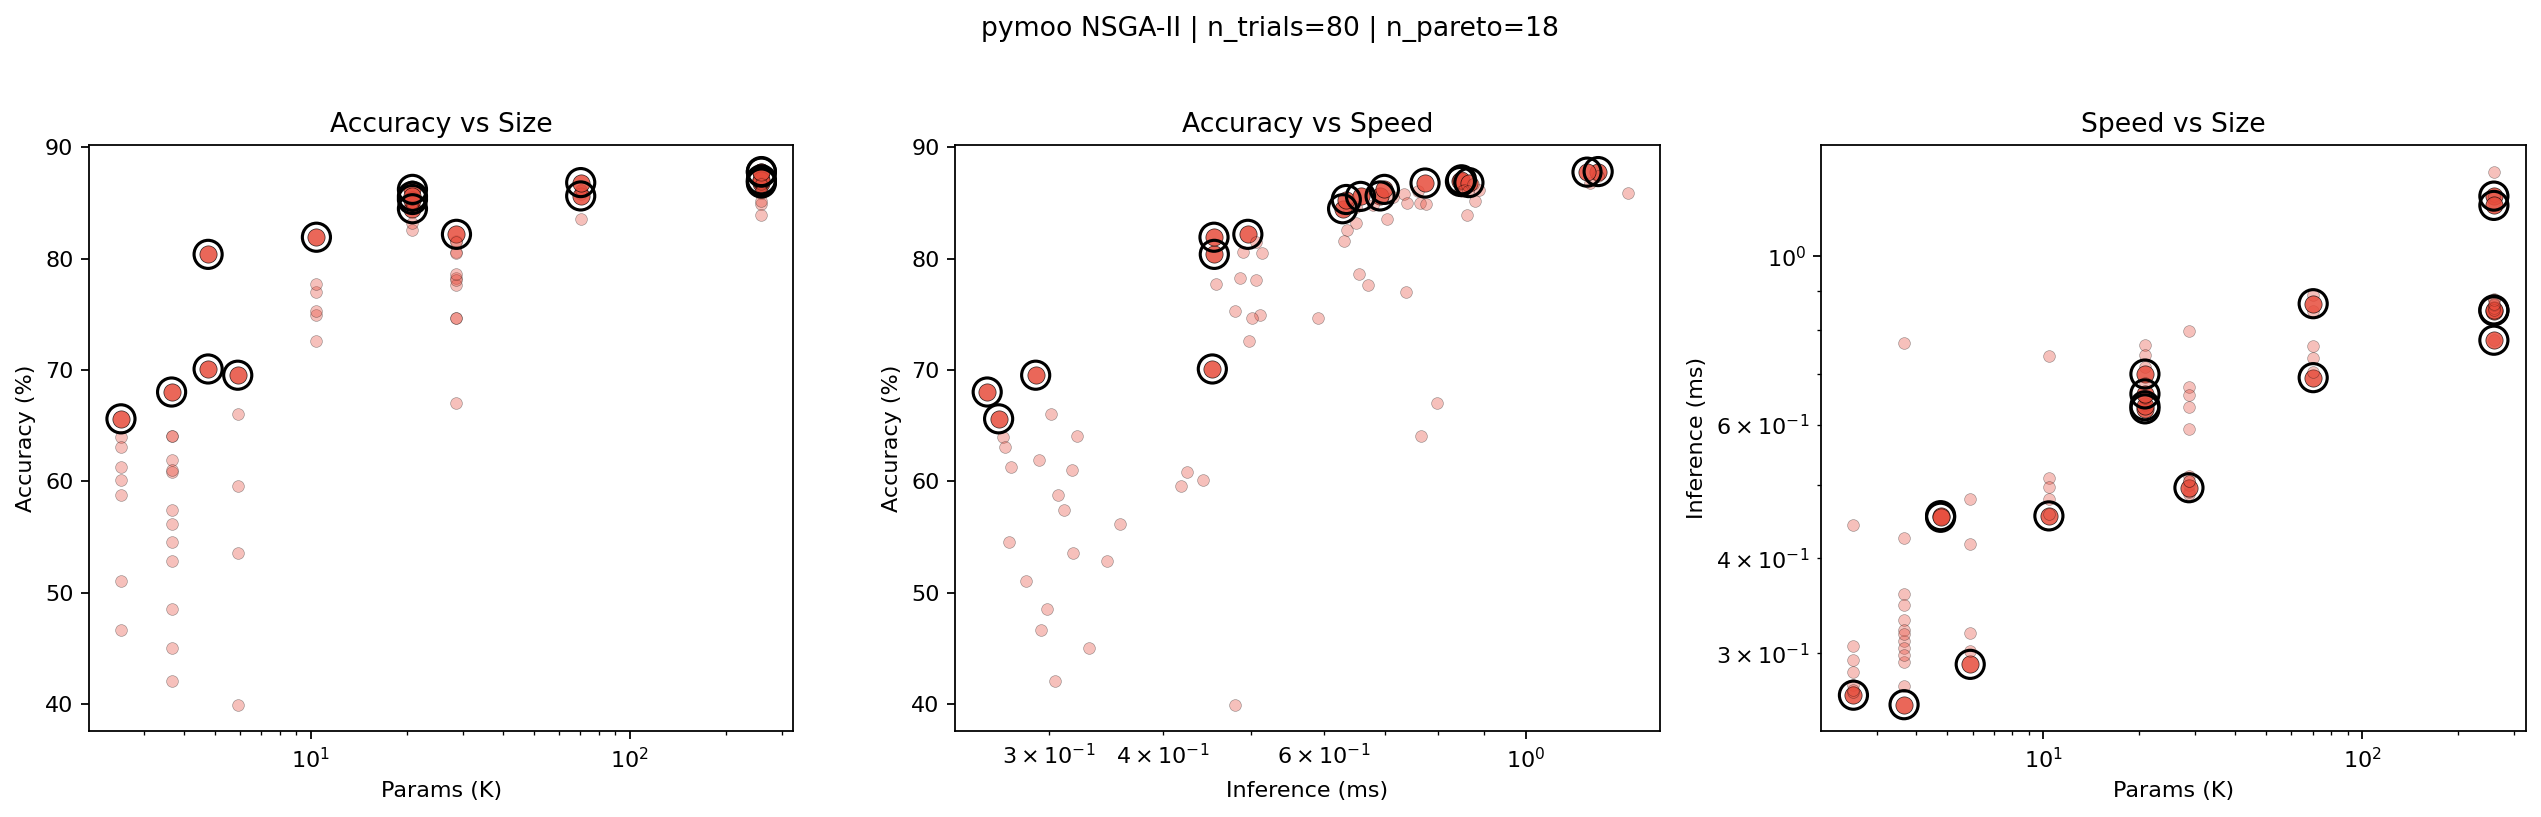

In [7]:
display(Image(filename=str(study_dir / "plot_2d_panels.png")))

### Parallel coordinates of the Pareto front
Each line is one Pareto-optimal solution; axes are normalized to `[0,1]` with **lower = better** (so accuracy is shown as `error_rate = 1-acc`).

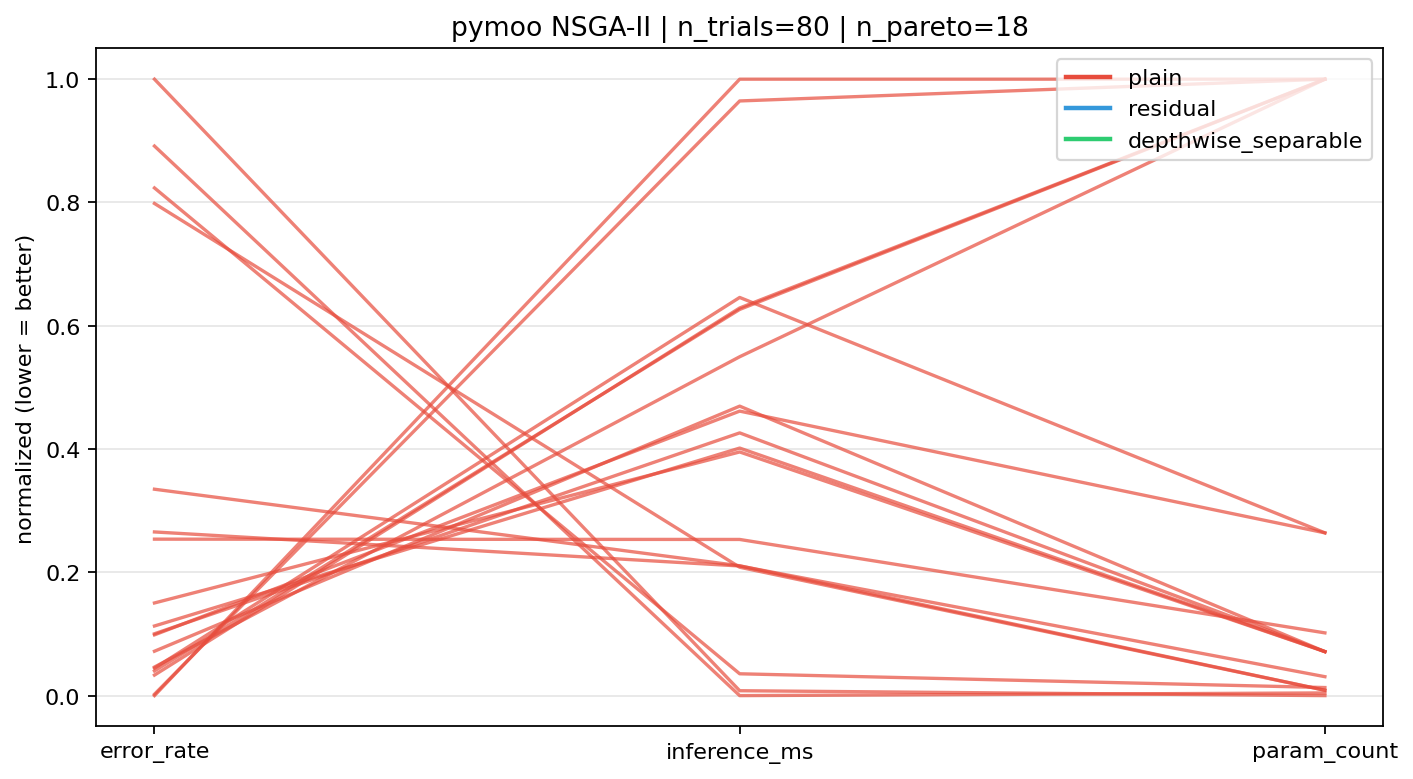

In [8]:
display(Image(filename=str(study_dir / "plot_parallel_coords.png")))

### 3D scatter — full objective space

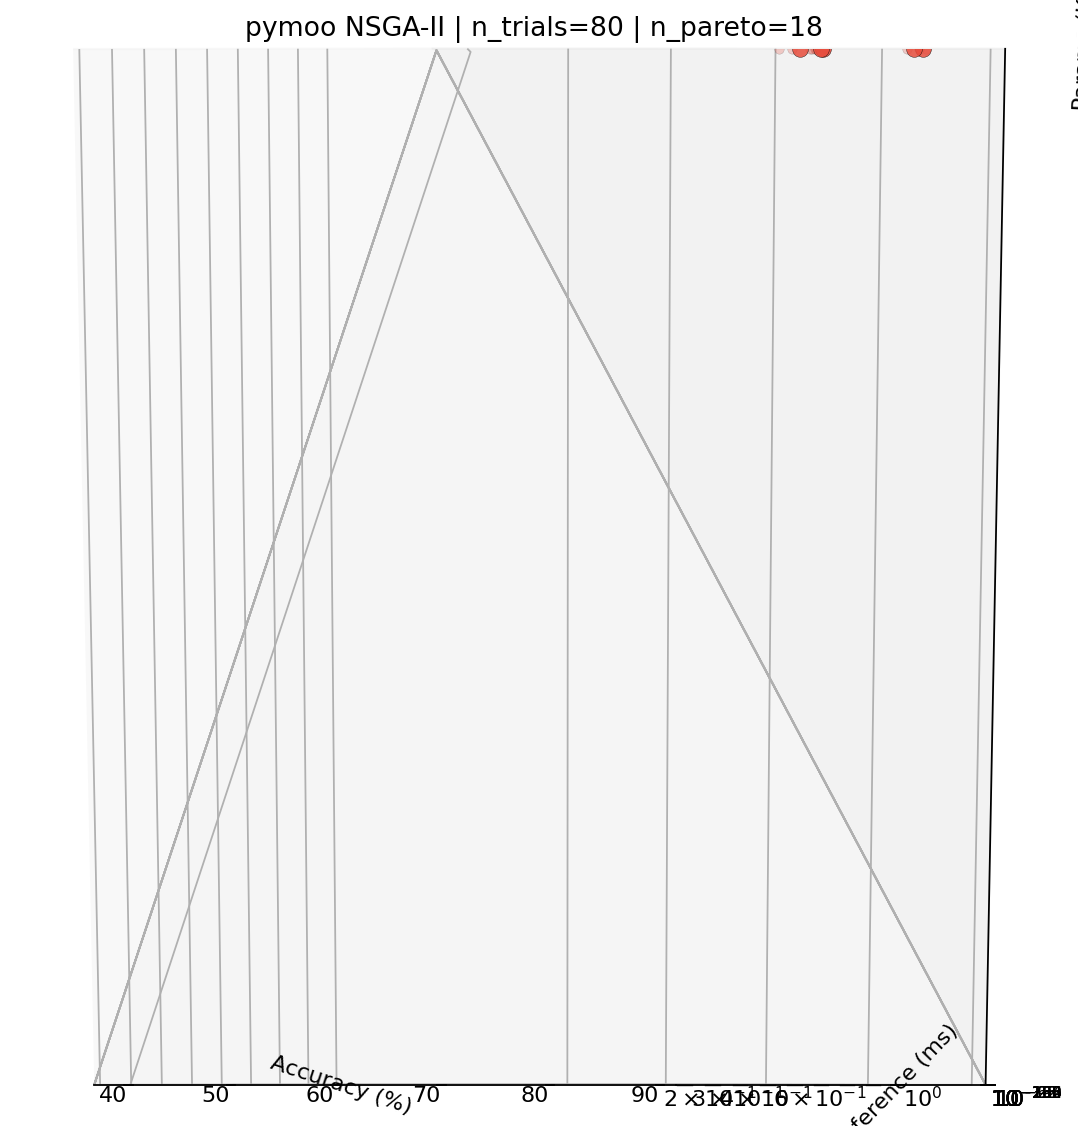

In [9]:
display(Image(filename=str(study_dir / "plot_3d_scatter.png")))

## Appendix — one fully-detailed Pareto-optimal solution
Selected as the **`balanced`** point: closest to the ideal `(max accuracy, min inference, min params)` in normalized objective space. This is what goes into the report's appendix section.

In [10]:
with open(study_dir / "appendix_solution.json") as f:
    appendix = json.load(f)

print(f"Label              : {appendix['label']}")
print(f"Trial number       : {appendix.get('trial_number')}")
print()
print("--- Objectives ---")
for k, v in appendix['objectives'].items():
    print(f"  {k:<14s} : {v}")
print()
print("--- Decision variables ---")
for k, v in appendix['decision_variables'].items():
    print(f"  {k:<18s} : {v}")

Label              : balanced (closest-to-ideal Pareto point)
Trial number       : 68

--- Objectives ---
  accuracy       : 0.8193
  inference_ms   : 0.454991
  param_count    : 10410

--- Decision variables ---
  arch_type          : plain
  num_conv_layers    : 2
  num_channels       : 16
  num_fc_units       : 128
  learning_rate      : 0.007743887859132244
  batch_size         : 16
  num_epochs         : 8
  dropout_rate       : 0.004859096464726154
  optimizer_type     : SGD
  input_resolution   : 16


## Compare against BoTorch (run after the BoTorch notebook finishes)
Once the BoTorch notebook has produced `results/botorch/<dataset>/<study>/pareto_front.csv`, set `COMPARE_PARETO` (config cell above) to that path and re-run the *Analysis* cell. The 2D panels will overlay magenta diamonds for the BoTorch front, and the metrics output will include joint-front survival counts plus generational distance — the head-to-head MOO comparison the rubric asks for.

In [11]:
# Helper: list the most recent BoTorch study dir for the chosen dataset.
candidate = PROJECT_ROOT / "results" / "botorch" / DATASET
if candidate.exists():
    runs = sorted([p for p in candidate.iterdir() if p.is_dir()])
    if runs:
        latest = runs[-1] / "pareto_front.csv"
        print(f"botorch latest pareto: {latest}")
        print(f"\nTo enable comparison, set in the config cell:\n  COMPARE_PARETO = r\"{latest}\"")
    else:
        print(f"(no botorch runs yet in {candidate})")
else:
    print(f"(no botorch results for dataset={DATASET})")

(no botorch results for dataset=fashion_mnist)
